In [ ]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.2.3

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir scikit-learn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

In [ ]:
import sys
print(sys.executable)

!{sys.executable} -m pip uninstall -y scikit-learn

In [1]:
import sys
!{sys.executable} -m pip install --no-cache-dir scikit-learn==1.5.2

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 2.0 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.0 MB 2.2 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.0 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.0 MB 2.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/11.0 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.0 MB 3.2 MB/s eta 0:00:03
   ------------------- -------------------- 5.2/11.0 MB 3.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.0 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.0 MB 3.2 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.0 MB 3.2 MB/s eta 0:00:02
   --------------------------- ------------ 7.6/11.0 MB 3.2 MB/s eta 0:00:02
   ----------

In [2]:
# Week 4 - Predictive Modeling and Optimization in Logistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the logistics dataset

df = pd.read_csv("data/logistics_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 10)


,Shipment_ID,Region,Vehicle_Type,Distance_km,Shipment_Volume_kg,Fuel_Cost,Delivery_Time_days,Transportation_Cost,Shipment_Date,Delay_Status
0,1,West,Container,906,4186,6017.51,7.88,18257.52,2025-01-01,Delayed
1,2,Central,Container,447,4483,2864.01,5.28,12413.78,2025-01-02,On Time
2,3,East,Container,336,1148,11899.98,5.03,12558.25,2025-01-03,On Time
3,4,Central,Container,654,2376,11149.44,5.44,14234.66,2025-01-04,On Time
4,5,Central,Container,28,3297,6073.15,2.24,7975.46,2025-01-05,On Time


In [4]:
# Basic inspection of the dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(1000, 10)

Column Names:
['Shipment_ID', 'Region', 'Vehicle_Type', 'Distance_km', 'Shipment_Volume_kg', 'Fuel_Cost', 'Delivery_Time_days', 'Transportation_Cost', 'Shipment_Date', 'Delay_Status']

Data Types:
Shipment_ID              int64
Region                  object
Vehicle_Type            object
Distance_km              int64
Shipment_Volume_kg       int64
Fuel_Cost              float64
Delivery_Time_days     float64
Transportation_Cost    float64
Shipment_Date           object
Delay_Status            object
dtype: object

Missing Values:
Shipment_ID            0
Region                 0
Vehicle_Type           0
Distance_km            0
Shipment_Volume_kg     0
Fuel_Cost              0
Delivery_Time_days     0
Transportation_Cost    0
Shipment_Date          0
Delay_Status           0
dtype: int64

Duplicate Rows:
0


In [5]:
print("Average Delivery Time:",
      round(df["Delivery_Time_days"].mean(), 2), "days")

print("Median Delivery Time:",
      round(df["Delivery_Time_days"].median(), 2), "days")

print("Average Transportation Cost:",
      round(df["Transportation_Cost"].mean(), 2))

print("Average Distance:",
      round(df["Distance_km"].mean(), 2), "km")

print("Average Shipment Volume:",
      round(df["Shipment_Volume_kg"].mean(), 2), "kg")

print("Average Fuel Cost:",
      round(df["Fuel_Cost"].mean(), 2))

Average Delivery Time: 4.89 days
Median Delivery Time: 4.86 days
Average Transportation Cost: 12599.84
Average Distance: 617.23 km
Average Shipment Volume: 2582.02 kg
Average Fuel Cost: 7628.93


In [6]:
# Define the prediction target and input features

target = "Delivery_Time_days"

features = [
    "Distance_km",
    "Shipment_Volume_kg",
    "Fuel_Cost"
]

X = df[features]
y = df[target]

print("Prediction Target:")
print(target)

print("\nFeatures used for prediction:")
print(features)

print("\nInput shape:", X.shape)
print("Target shape:", y.shape)

Prediction Target:
Delivery_Time_days

Features used for prediction:
['Distance_km', 'Shipment_Volume_kg', 'Fuel_Cost']

Input shape: (1000, 3)
Target shape: (1000,)


TRAIN / TEST SPLIT
Training samples: 800
Testing samples : 200

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Linear Regression,0.7536,0.9425,0.7354
1,Decision Tree,0.9001,1.1263,0.6222
2,Random Forest,0.8156,1.0180,0.6913



Best initial model based on RMSE:
Linear Regression

5-FOLD CROSS VALIDATION
CV MAE scores:
Fold 1: 0.8372
Fold 2: 0.8071
Fold 3: 0.8168
Fold 4: 0.8720
Fold 5: 0.8868

Average CV MAE: 0.844

HYPERPARAMETER TUNING
Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

TUNED RANDOM FOREST RESULTS
MAE : 0.7784
RMSE: 0.9724
R²  : 0.7184

FEATURE IMPORTANCE


,Feature,Importance
0,Distance_km,0.9585
1,Shipment_Volume_kg,0.0218
2,Fuel_Cost,0.0198


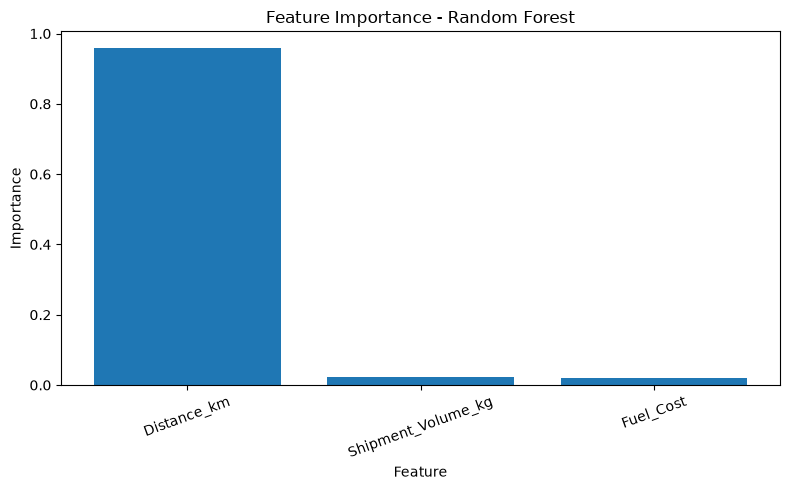

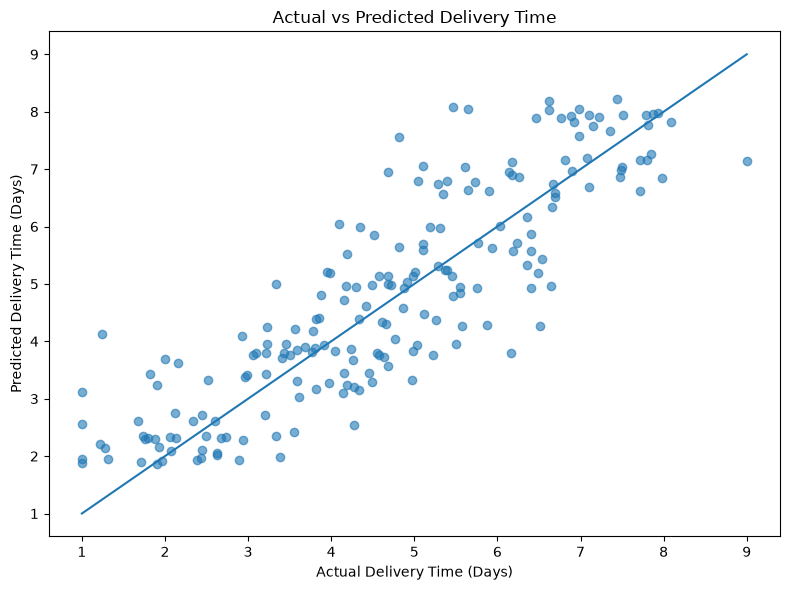


SAMPLE PREDICTIONS


,Actual_Delivery_Time,Predicted_Delivery_Time,Error
0,1.91,1.86,0.05
1,4.68,5.14,-0.46
2,7.98,6.84,1.14
3,5.04,6.79,-1.75
4,4.09,6.04,-1.95
5,7.87,7.96,-0.09
6,4.15,4.72,-0.57
7,3.82,4.39,-0.57
8,4.57,5.13,-0.56
9,4.82,5.63,-0.81



SHIPMENT RISK ANALYSIS
Risk_Level
Normal       750
High Risk    250
Name: count, dtype: int64

FINAL WEEK 4 SUMMARY
Best initial model: Linear Regression

Tuned Random Forest:
MAE : 0.7784
RMSE: 0.9724
R²  : 0.7184

Average Cross-Validation MAE: 0.844

Most important features:


,Feature,Importance
0,Distance_km,0.9585
1,Shipment_Volume_kg,0.0218
2,Fuel_Cost,0.0198



Analysis completed successfully!


In [7]:
# ============================================================
# WEEK 4 - COMPLETE PREDICTIVE MODELING ANALYSIS
# ============================================================

# 1. Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# 2. Linear Regression
# ------------------------------------------------------------

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)


# 3. Decision Tree
# ------------------------------------------------------------

tree_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)


# 4. Random Forest
# ------------------------------------------------------------

forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)


# 5. Evaluation Function
# ------------------------------------------------------------

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# 6. Compare Models
# ------------------------------------------------------------

results = [

    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        forest_predictions
    )
]

results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    results_df.round(4)
)


# 7. Select Best Initial Model
# ------------------------------------------------------------

best_initial_model = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("\nBest initial model based on RMSE:")
print(best_initial_model["Model"])


# 8. 5-Fold Cross Validation
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5-FOLD CROSS VALIDATION")
print("=" * 60)

cv_scores = cross_val_score(
    forest_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_mae_scores = -cv_scores

print("CV MAE scores:")

for i, score in enumerate(cv_mae_scores, 1):
    print(
        f"Fold {i}: {score:.4f}"
    )

print(
    "\nAverage CV MAE:",
    round(cv_mae_scores.mean(), 4)
)


# 9. Hyperparameter Tuning
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

param_grid = {

    "n_estimators": [
        100,
        200
    ],

    "max_depth": [
        5,
        10,
        15
    ],

    "min_samples_split": [
        2,
        5
    ]
}

grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    param_grid,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")

print(
    grid_search.best_params_
)


# 10. Tuned Random Forest
# ------------------------------------------------------------

tuned_model = grid_search.best_estimator_

tuned_predictions = tuned_model.predict(
    X_test
)


tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)


print("\n" + "=" * 60)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 60)

print(
    "MAE :",
    round(tuned_mae, 4)
)

print(
    "RMSE:",
    round(tuned_rmse, 4)
)

print(
    "R²  :",
    round(tuned_r2, 4)
)


# 11. Feature Importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        tuned_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

display(
    feature_importance.round(4)
)


# 12. Feature Importance Chart
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title(
    "Feature Importance - Random Forest"
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Importance"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# 13. Actual vs Predicted Chart
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)

plt.xlabel(
    "Actual Delivery Time (Days)"
)

plt.ylabel(
    "Predicted Delivery Time (Days)"
)

plt.title(
    "Actual vs Predicted Delivery Time"
)

min_value = min(
    y_test.min(),
    tuned_predictions.min()
)

max_value = max(
    y_test.max(),
    tuned_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.tight_layout()

plt.show()


# 14. Prediction Error Table
# ------------------------------------------------------------

prediction_results = pd.DataFrame({

    "Actual_Delivery_Time":
        y_test.values,

    "Predicted_Delivery_Time":
        tuned_predictions

})

prediction_results["Error"] = (
    prediction_results["Actual_Delivery_Time"]
    -
    prediction_results["Predicted_Delivery_Time"]
)

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

display(
    prediction_results.head(10).round(2)
)


# 15. Identify High-Risk Shipments
# ------------------------------------------------------------

df["Predicted_Delivery_Risk"] = (
    df["Distance_km"] * 0.5
    +
    df["Fuel_Cost"] * 0.0005
)

risk_limit = df[
    "Predicted_Delivery_Risk"
].quantile(0.75)

df["Risk_Level"] = np.where(
    df["Predicted_Delivery_Risk"] >= risk_limit,
    "High Risk",
    "Normal"
)

print("\n" + "=" * 60)
print("SHIPMENT RISK ANALYSIS")
print("=" * 60)

print(
    df["Risk_Level"].value_counts()
)


# 16. Final Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL WEEK 4 SUMMARY")
print("=" * 60)

print(
    "Best initial model:",
    best_initial_model["Model"]
)

print(
    "\nTuned Random Forest:"
)

print(
    "MAE :",
    round(tuned_mae, 4)
)

print(
    "RMSE:",
    round(tuned_rmse, 4)
)

print(
    "R²  :",
    round(tuned_r2, 4)
)

print(
    "\nAverage Cross-Validation MAE:",
    round(cv_mae_scores.mean(), 4)
)

print(
    "\nMost important features:"
)

display(
    feature_importance.round(4)
)

print("\nAnalysis completed successfully!")